In [2]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(ggplot2)
library(patchwork)
library(FELLA)
library(readxl)
library(readr)
library(KEGGREST)
library(httr)
library(jsonlite)

Warning message:
“package ‘clusterProfiler’ was built under R version 4.3.2”


clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Warning message:
“package ‘AnnotationDbi’ was built under R version 4.3.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

  

In [3]:
load("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/metabolite_FELLA_pathway_positive_negative.Rdata")

In [9]:
metabolite <- read.csv("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_age_linear_gender_FDR.csv",row.names=1) #age not scale
head(metabolite)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig
Estimate1,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig
Estimate2,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no
Estimate3,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no
Estimate4,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no
Estimate5,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no


In [13]:
metabolite_annotation <- read_tsv("/vol/projects/CIIM/cohorts_old/500FG/metabolic/500FG raw metabolite_fromJianbo.tsv")
head(metabolite_annotation)
dim(metabolite_annotation)

Rows: 1596 Columns: 479
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (5): database_identifier, chemical_formula, smiles, inchi, metabolite_...
dbl (460): mass_to_charge, reliability, HV001, HV002, HV003, HV004, HV005, H...
lgl  (14): fragmentation, modifications, charge, retention_time, taxid, spec...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


database_identifier,chemical_formula,smiles,inchi,metabolite_identification,mass_to_charge,fragmentation,modifications,charge,retention_time,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CHEBI:10022,C15H20O6,[H][C@@]12O[C@]3([H])C=C(C)C(=O)[C@@H](O)[C@]3(CO)[C@@](C)(C[C@H]1O)[C@]21CO1,"InChI=1S/C15H20O6/c1-7-3-9-14(5-16,11(19)10(7)18)13(2)4-8(17)12(21-9)15(13)6-20-15/h3,8-9,11-12,16-17,19H,4-6H2,1-2H3/t8-,9-,11-,12-,13-,14-,15+/m1/s1",Deoxynivalenol,295.1191,NA,NA,NA,NA,⋯,18349.0,44987.5,22414.5,19734.0,21075.5,16550.0,20302.0,12916.5,13331.0,36608.0
CHEBI:10075,C16H16O3,COc1cc(O)ccc1C\C=C\c1ccc(O)cc1,"InChI=1S/C16H16O3/c1-19-16-11-15(18)10-7-13(16)4-2-3-12-5-8-14(17)9-6-12/h2-3,5-11,17-18H,4H2,1H3/b3-2+",Xenognosin A,255.1038,NA,NA,NA,NA,⋯,17442.5,23112.5,18458.0,15341.0,17501.0,12886.5,13475.0,20116.5,18011.5,18617.5
CHEBI:10137,C17H26O3,CCCCCCCC(=O)CCc1ccc(O)c(OC)c1,"InChI=1S/C17H26O3/c1-3-4-5-6-7-8-15(18)11-9-14-10-12-16(19)17(13-14)20-2/h10,12-13,19H,3-9,11H2,1-2H3",1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,277.1809,NA,NA,NA,NA,⋯,410828.5,424573.0,784687.0,294914.5,864931.0,356691.0,424070.5,382228.5,465130.0,370595.5
CHEBI:10366,C7H14O4,[H]C([H])(C=O)[C@]([H])(OC)[C@]([H])(O)[C@@]([H])(C)O,"InChI=1S/C7H14O4/c1-5(9)7(10)6(11-2)3-4-8/h4-7,9-10H,3H2,1-2H3/t5-,6+,7-/m1/s1",Cymarose,161.0819,NA,NA,NA,NA,⋯,10493.0,10690.0,10907.5,9893.0,11671.5,10216.5,11271.0,10342.5,10849.5,9935.5
CHEBI:10368,C7H14O5,[H][C@](C)(O)[C@]([H])(O)[C@]([H])(OC)[C@@]([H])(O)C=O,"InChI=1S/C7H14O5/c1-4(9)6(11)7(12-2)5(10)3-8/h3-7,9-11H,1-2H3/t4-,5+,6+,7-/m1/s1",Digitalose,177.0772,NA,NA,NA,NA,⋯,17688.0,14362.5,16077.5,14465.5,19710.0,14843.5,14253.5,15513.0,13962.5,13581.0
CHEBI:10432,C10H8O,Oc1ccc2ccccc2c1,"InChI=1S/C10H8O/c11-10-6-5-8-3-1-2-4-9(8)7-10/h1-7,11H",2-Naphthol,143.0493,NA,NA,NA,NA,⋯,24687.0,20415.5,23917.5,19506.5,20907.0,18360.0,18922.0,19580.0,17712.0,16752.5


[1] 1596  479

In [19]:
head(chebi_ids)

[1] "CHEBI:10075"  "CHEBI:125536" "CHEBI:131691" "CHEBI:132966" "CHEBI:133086"
[6] "CHEBI:133478"

In [30]:
output_dir <- "/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment"

# 1. Match: feature -> metabolite_identification -> database_identifier
# Use "sig" or "significant" depending on your metabolite table
metab_sig <- metabolite[metabolite$sig %in% c("sig", "significant"), ]
if (nrow(metab_sig) == 0) stop("No significant metabolites. Check metabolite$sig (e.g. 'sig' or 'significant') or filter by padj < 0.05.")
idx <- match(metab_sig$feature, metabolite_annotation$metabolite_identification)
metab_sig$database_identifier <- metabolite_annotation$database_identifier[idx]
metab_sig <- metab_sig[!is.na(metab_sig$database_identifier), ]

# If database_identifier has multiple IDs in one cell (e.g. "CHEBI:10075''CHEBI:125536''..."), split them
all_chebi <- unlist(strsplit(as.character(metab_sig$database_identifier), "''", fixed = TRUE))
all_chebi <- trimws(all_chebi)
all_chebi <- all_chebi[nzchar(all_chebi)]
chebi_ids <- unique(all_chebi) 

# 2. CHEBI -> KEGG (strip "CHEBI:" prefix)
# Keep only sig
metab_sig <- metabolite[metabolite$sig == "sig", ]
# Match: feature -> metabolite_identification -> database_identifier
idx <- match(metab_sig$feature, metabolite_annotation$metabolite_identification)
metab_sig$database_identifier <- metabolite_annotation$database_identifier[idx]
# Drop rows that did not match
metab_sig <- metab_sig[!is.na(metab_sig$database_identifier), ]
# If database_identifier has multiple IDs in one cell (e.g. "CHEBI:10075''CHEBI:125536''..."), split them
all_chebi <- unlist(strsplit(as.character(metab_sig$database_identifier), "''", fixed = TRUE))
all_chebi <- trimws(all_chebi)
all_chebi <- all_chebi[nzchar(all_chebi)]
chebi_ids <- unique(all_chebi)   # now a vector of single IDs, e.g. c("CHEBI:10075", "CHEBI:125536", ...)

# ---------------------------------------------------------------------
# 2. KEGG name search is stable; CHEBI bulk link often fails.
# ---------------------------------------------------------------------
message("Mapping metabolite names -> KEGG (keggFind)...")
names_for_search <- unique(metab_sig$feature)
kegg_ids <- character(length(names_for_search))
for (i in seq_along(names_for_search)) {
  Sys.sleep(0.35)
  tryCatch({
    r <- keggFind("compound", names_for_search[i])
    if (length(r) > 0) kegg_ids[i] <- names(r)[1]
  }, error = function(e) {})
}
kegg_ids <- unique(kegg_ids[nzchar(kegg_ids)])
if (length(kegg_ids) == 0) stop("No compounds mapped to KEGG. Check metabolite_identification names.")
message("Mapped ", length(kegg_ids), " / ", length(names_for_search), " compounds to KEGG.")


Mapping metabolite names -> KEGG (keggFind)...

Mapped 134 / 569 compounds to KEGG.



In [40]:
graph_dir <- file.path(output_dir, "FELLA_graph")
databaseDir <- file.path(output_dir, "FELLA_db")
dir.create(graph_dir, showWarnings = FALSE, recursive = TRUE)
graph_path <- file.path(graph_dir, "graph.rds")
keggdata_path <- file.path(databaseDir, "keggdata.graph.RData")

if (!file.exists(graph_path)) {
  message("Building KEGG graph (first time, may take a while)...")
  fella_graph <- buildGraphFromKEGGREST(organism = "hsa")
  saveRDS(fella_graph, graph_path)
} else {
  fella_graph <- readRDS(graph_path)
}

if (!file.exists(keggdata_path)) {
  message("Building FELLA database (keggdata.graph.RData, one-time)...")
  # databaseDir must not exist; buildDataFromGraph creates it
  buildDataFromGraph(
    keggdata.graph = fella_graph,
    databaseDir = databaseDir,
    internalDir = FALSE
  )
}

fella_data <- loadKEGGdata(
  databaseDir = databaseDir,
  internalDir = FALSE
)

# Keep only compounds that exist in FELLA's KEGG data to avoid "None of the specified compounds appear..."
g <- getGraph(fella_data)
graph_node_names <- igraph::V(g)$name
# Compound nodes: allow "C12345" or "cpd:C12345"
raw_compounds <- grep("C[0-9]+", graph_node_names, value = TRUE)
normalize_kegg_cpd <- function(x) {
  x <- sub("^cpd:", "", x, ignore.case = TRUE)
  x <- sub("^compound:", "", x, ignore.case = TRUE)
  # KEGG standard: C + 5 digits (vector-safe)
  mask <- grepl("^C([0-9]+)$", x)
  num <- sub("^C", "", x[mask])
  x[mask] <- paste0("C", sprintf("%05d", as.integer(num)))
  x
}
valid_compounds <- unique(normalize_kegg_cpd(raw_compounds))
valid_compounds <- valid_compounds[nzchar(valid_compounds)]

# Your kegg_ids from keggFind: normalize to C + 5 digits for matching
kegg_ids_norm <- vapply(kegg_ids, function(id) {
  id <- sub("^cpd:", "", id, ignore.case = TRUE)
  if (grepl("^C([0-9]+)$", id)) {
    num <- sub("^C", "", id)
    id <- paste0("C", sprintf("%05d", as.integer(num)))
  }
  id
}, character(1), USE.NAMES = FALSE)
kegg_ids_valid <- intersect(kegg_ids_norm, valid_compounds)
# Pass 5-digit normalized IDs to FELLA (same format as graph)
idx_valid <- kegg_ids_norm %in% kegg_ids_valid
kegg_ids_for_enrich <- unique(kegg_ids_norm[idx_valid])
message("Sample graph compound IDs: ", paste(head(valid_compounds, 5), collapse = ", "))
message("Sample your KEGG IDs (normalized): ", paste(head(kegg_ids_norm, 5), collapse = ", "))
message("Compounds in FELLA graph: ", length(kegg_ids_for_enrich), " / ", length(kegg_ids))
if (length(kegg_ids_for_enrich) == 0) {
  stop(
    "None of your KEGG IDs are in FELLA's human pathway graph. ",
    "Graph uses format like: ", paste(head(valid_compounds, 3), collapse = ", "), ". ",
    "Yours: ", paste(head(kegg_ids, 3), collapse = ", ")
  )
}

res <- enrich(
  compounds = kegg_ids_for_enrich,
  data = fella_data,
  method = "diffusion"
)
# generateResultsTable(method, threshold, plimit, nlimit, ..., object, data)
# Must use object= and data= so res/fella_data are not matched to method/threshold
tab <- tryCatch(
  generateResultsTable(
    object = res,
    data = fella_data,
    method = "diffusion",
    threshold = 0.05,
    plimit = 15,
    nlimit = 250
  ),
  error = function(e) {
    message("generateResultsTable error: ", conditionMessage(e))
    saveRDS(res, file.path(output_dir, "FELLA_enrich_result.rds"))
    NULL
  }
)

if (!is.null(tab) && is.data.frame(tab) && nrow(tab) > 0) {
  print(head(tab, 20))
  write.csv(tab, file.path(output_dir, "FELLA_pathway_enrichment_results.csv"), row.names = FALSE)
} else {
  message("No table produced. Saving enrichment object for inspection.")
  saveRDS(res, file.path(output_dir, "FELLA_enrich_result.rds"))
}


Loading KEGG graph data...

Done.

Loading hypergeom data...

Loading matrix...

Done.

Loading diffusion data...

Loading matrix...

'diffusion.matrix.RData' not loaded. Simulated permutations may execute slower for diffusion.

Done.

Loading rowSums...

Done.

Loading pagerank data...

Loading matrix...

'pagerank.matrix.RData' not loaded. Simulated permutations may execute slower for pagerank.

Done.

Loading rowSums...

Done.

Data successfully loaded.

Sample graph compound IDs: C00001, C00002, C00003, C00004, C00005

Sample your KEGG IDs (normalized): C08731, C01586, C11457, C00777, C00964

Compounds in FELLA graph: 76 / 134

No background compounds specified. Default background will be used.

Running diffusion...

Computing p-scores through the specified distribution.

Done.

Writing diffusion results...

Done.



       KEGG.id Entry.type                                        KEGG.name
1     hsa00010    pathway Glycolysis / Gluconeogenesis - Homo sapiens (...
2     hsa00232    pathway       Caffeine metabolism - Homo sapiens (human)
3     hsa04081    pathway         Hormone signaling - Homo sapiens (human)
4     hsa04082    pathway Neuroactive ligand signaling - Homo sapiens (...
5     hsa04261    pathway Adrenergic signaling in cardiomyocytes - Homo...
6     hsa04659    pathway Th17 cell differentiation - Homo sapiens (hum...
7     hsa04713    pathway     Circadian entrainment - Homo sapiens (human)
8     hsa04742    pathway        Taste transduction - Homo sapiens (human)
9     hsa04924    pathway           Renin secretion - Homo sapiens (human)
10    hsa05230    pathway Central carbon metabolism in cancer - Homo sa...
11      M00042     module Catecholamine biosynthesis, tyrosine => dopam...
12    1.1.1.34     enzyme      hydroxymethylglutaryl-CoA reductase (NADPH)
13   1.1.1.399     enzyme

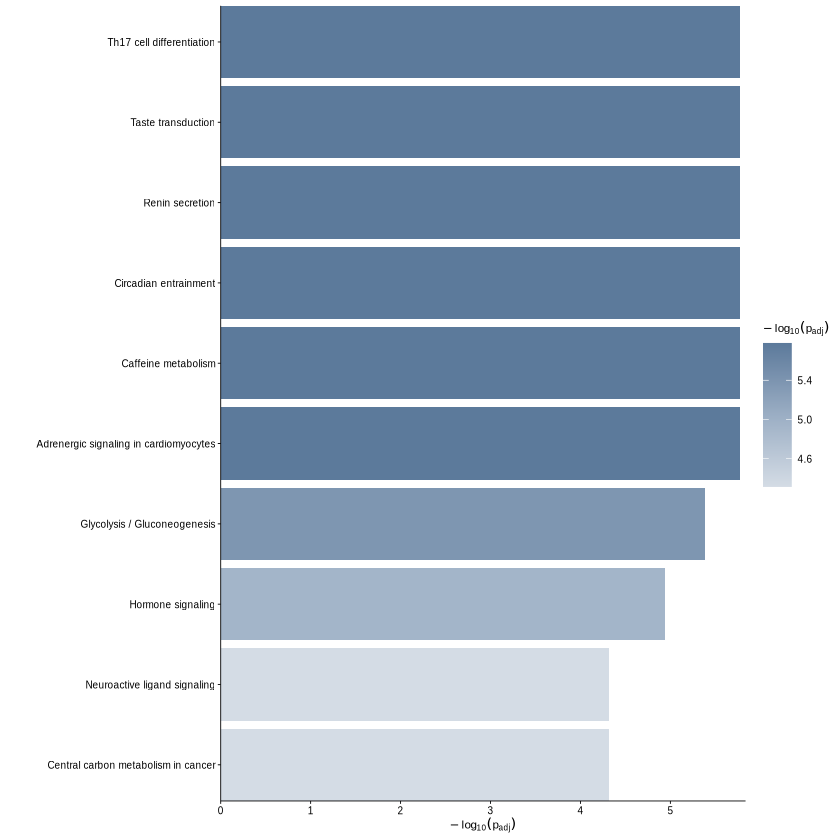

In [64]:
pathway_only <- tab[tab$Entry.type == "pathway", ]

# User-defined palette; gradient from light to dark for low to high -log10(p)
palette_nature <- c("#B2DF8A", "#6A3D9A", "#FFFF99", "#FF7F00", "#A6CEE3", "#CAB2D6", "#e8d5b7", "#dcd6f7")
#fill_colors <- c("#A6CEE3", "#CAB2D6", "#6A3D9A")
fill_colors <- c("#D4DCE5", "#9BAEC4", "#5C7A9B")
 # fill_colors <- c("#E8E4F0", "#C9C0DC", "#8B7B9E")
 # fill_colors <- c("#dcd6f7", "#CAB2D6", "#6A3D9A")
 # fill_colors <- c("#B2DF8A", "#FFFF99", "#FF7F00")

# Adjusted p-value (Benjamini-Hochberg); FELLA table has p.score only
pathway_only$padj <- p.adjust(pathway_only$p.score, method = "BH")
pathway_only$neglog10padj <- -log10(pathway_only$padj)
# Sort by p.score and take top N
n_show <- 15
pathway_only <- pathway_only[order(pathway_only$p.score), ][1:min(n_show, nrow(pathway_only)), ]
# Remove " - Homo sapiens (human)" and any variant (e.g. " - Homo sa...", " - Homo...")
pathway_only$KEGG.name_short <- gsub(" \\- Homo.*$", "", pathway_only$KEGG.name)
pathway_only$KEGG.name_short <- trimws(pathway_only$KEGG.name_short)
pathway_only$KEGG.name_short <- substr(pathway_only$KEGG.name_short, 1, 55)  # truncate if still long

# Nature Aging figure specs: sans-serif font, 5-7 pt, no grid, axis labels with units, vector output
x_max <- max(pathway_only$neglog10padj) * 1.01
p_bar <- ggplot(pathway_only, aes(x = reorder(KEGG.name_short, neglog10padj), y = neglog10padj, fill = neglog10padj)) +
  geom_col() +
  coord_flip() +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_continuous(limits = c(0, x_max), expand = c(0, 0)) +
  scale_fill_gradientn(colors = fill_colors, name = expression(-log[10](p[adj]))) +
  labs(x = "", y = expression(-log[10](p[adj]))) +
  theme_classic(base_size = 7, base_family = "sans") +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 7),
    legend.text = element_text(size = 6),
    axis.text = element_text(size = 6, colour = "black"),
    axis.title = element_text(size = 7, colour = "black"),
    axis.line = element_line(colour = "black", linewidth = 0.25),
    axis.ticks = element_line(colour = "black", linewidth = 0.25),
    panel.grid = element_blank(),
    plot.title = element_blank()
  )

print(p_bar)

# Nature single column 89 mm, double column 183 mm; save vector PDF for submission
fig_width_mm <- 89   # single column
fig_height_mm <- max(60, nrow(pathway_only) * 12)
ggsave("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/metabolite_FELLA_pathway_barplot.pdf", p_bar, width = fig_width_mm/25.4, height = fig_height_mm/25.4, units = "in", useDingbats = FALSE)
ggsave("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/metabolite_FELLA_pathway_barplot.png", p_bar, width = fig_width_mm/25.4, height = fig_height_mm/25.4, units = "in", dpi = 300)



In [66]:
save.image("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/metabolite_FELLA_pathway.Rdata")

In [2]:
load("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/metabolite_FELLA_pathway.Rdata")

In [ ]:
###seperate upregulted and down regulated
# Pathway enrichment: split by estimate > 0 vs < 0
# Requires: metabolite (with feature, sig, estimate), metabolite_annotation (metabolite_identification, database_identifier)

output_dir <- "/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment"
result_dir <- file.path(output_dir, "FELLA_results_gender")  # 新目录名自定
dir.create(result_dir, showWarnings = FALSE, recursive = TRUE)
graph_dir <- file.path(output_dir, "FELLA_graph")
databaseDir <- file.path(output_dir, "FELLA_db")
dir.create(graph_dir, showWarnings = FALSE, recursive = TRUE)
graph_path <- file.path(graph_dir, "graph.rds")
keggdata_path <- file.path(databaseDir, "keggdata.graph.RData")

# ---- One-time: FELLA graph & database ----
if (!file.exists(graph_path)) {
  message("Building KEGG graph (first time)...")
  fella_graph <- buildGraphFromKEGGREST(organism = "hsa")
  saveRDS(fella_graph, graph_path)
} else {
  fella_graph <- readRDS(graph_path)
}
if (!file.exists(keggdata_path)) {
  message("Building FELLA database (one-time)...")
  buildDataFromGraph(keggdata.graph = fella_graph, databaseDir = databaseDir, internalDir = FALSE)
}
fella_data <- loadKEGGdata(databaseDir = databaseDir, internalDir = FALSE)

# ---- One-time: valid compound set & normalizer ----
g <- getGraph(fella_data)
raw_compounds <- grep("C[0-9]+", igraph::V(g)$name, value = TRUE)
normalize_kegg_cpd <- function(x) {
  x <- sub("^cpd:|^compound:", "", x, ignore.case = TRUE)
  mask <- grepl("^C([0-9]+)$", x)
  x[mask] <- paste0("C", sprintf("%05d", as.integer(sub("^C", "", x[mask]))))
  x
}
valid_compounds <- unique(normalize_kegg_cpd(raw_compounds))
valid_compounds <- valid_compounds[nzchar(valid_compounds)]

# ---- Per group: get metab_sig -> KEGG IDs -> enrich ----
run_enrich_for_group <- function(metab_sub, group_name, out_dir) {
  if (nrow(metab_sub) == 0) {
    message("Group ", group_name, ": no metabolites, skip.")
    return(invisible(NULL))
  }
  names_for_search <- unique(metab_sub$feature)
  kegg_ids <- character(length(names_for_search))
  for (i in seq_along(names_for_search)) {
    Sys.sleep(0.35)
    tryCatch({
      r <- keggFind("compound", names_for_search[i])
      if (length(r) > 0) kegg_ids[i] <- names(r)[1]
    }, error = function(e) {})
  }
  kegg_ids <- unique(kegg_ids[nzchar(kegg_ids)])
  if (length(kegg_ids) == 0) {
    message("Group ", group_name, ": no KEGG mapping, skip.")
    return(invisible(NULL))
  }
  kegg_ids_norm <- vapply(kegg_ids, function(id) {
    id <- sub("^cpd:", "", id, ignore.case = TRUE)
    if (grepl("^C([0-9]+)$", id)) id <- paste0("C", sprintf("%05d", as.integer(sub("^C", "", id))))
    id
  }, character(1), USE.NAMES = FALSE)
  kegg_ids_for_enrich <- unique(intersect(kegg_ids_norm, valid_compounds))
  if (length(kegg_ids_for_enrich) == 0) {
    message("Group ", group_name, ": no compounds in FELLA graph, skip.")
    return(invisible(NULL))
  }
  message("Group ", group_name, ": ", length(kegg_ids_for_enrich), " compounds -> enrich.")
  res <- enrich(compounds = kegg_ids_for_enrich, data = fella_data, method = "diffusion")
  tab <- tryCatch(
    generateResultsTable(object = res, data = fella_data, method = "diffusion", threshold = 0.05, plimit = 15, nlimit = 250),
    error = function(e) {
      message("generateResultsTable error: ", conditionMessage(e))
      saveRDS(res, file.path(out_dir, paste0("FELLA_enrich_result_", group_name, ".rds")))
      return(NULL)
    }
  )
  if (!is.null(tab) && nrow(tab) > 0) {
    write.csv(tab, file.path(out_dir, paste0("FELLA_pathway_enrichment_", group_name, ".csv")), row.names = FALSE)
    message("Group ", group_name, ": wrote ", nrow(tab), " rows.")
  }
  invisible(NULL)
}

# ---- Run both groups ----
metab_sig_all <- metabolite[metabolite$sig %in% c("sig", "significant"), ]
if (nrow(metab_sig_all) == 0) stop("No significant metabolites. Check metabolite$sig.")

run_enrich_for_group(metab_sig_all[metab_sig_all$estimate > 0, ], "estimate_positive", result_dir)
run_enrich_for_group(metab_sig_all[metab_sig_all$estimate < 0, ], "estimate_negative", result_dir)


Loading KEGG graph data...

Done.

Loading hypergeom data...

Loading matrix...

Done.

Loading diffusion data...

Loading matrix...

'diffusion.matrix.RData' not loaded. Simulated permutations may execute slower for diffusion.

Done.

Loading rowSums...

Done.

Loading pagerank data...

Loading matrix...

'pagerank.matrix.RData' not loaded. Simulated permutations may execute slower for pagerank.

Done.

Loading rowSums...

Done.

Data successfully loaded.

Group estimate_positive: 42 compounds -> enrich.

No background compounds specified. Default background will be used.

Running diffusion...

Computing p-scores through the specified distribution.

Done.

Writing diffusion results...

Done.

Group estimate_positive: wrote 250 rows.

Group estimate_negative: 39 compounds -> enrich.

No background compounds specified. Default background will be used.

Running diffusion...

Computing p-scores through the specified distribution.



In [5]:
# pos <- read.csv("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/FELLA_pathway_enrichment_estimate_positive.csv")
# neg <- read.csv("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/FELLA_pathway_enrichment_estimate_negative.csv")
pos <- read.csv(file.path(result_dir, "FELLA_pathway_enrichment_estimate_positive.csv"))
neg <- read.csv(file.path(result_dir, "FELLA_pathway_enrichment_estimate_negative.csv"))
names(pos)
head(pos, 10)
head(neg, 10)

[1] "KEGG.id"    "Entry.type" "KEGG.name"  "p.score"

,KEGG.id,Entry.type,KEGG.name,p.score
,<chr>,<chr>,<chr>,<dbl>
1,hsa00010,pathway,Glycolysis / Gluconeogenesis - Homo sapiens (...,1.000000e-06
2,hsa00220,pathway,Arginine biosynthesis - Homo sapiens (human),2.261174e-06
3,hsa00232,pathway,Caffeine metabolism - Homo sapiens (human),1.000000e-06
4,hsa00360,pathway,Phenylalanine metabolism - Homo sapiens (huma...,1.000000e-06
5,hsa00590,pathway,Arachidonic acid metabolism - Homo sapiens (h...,1.849037e-05
6,hsa03018,pathway,RNA degradation - Homo sapiens (human),1.608127e-03
7,hsa04080,pathway,Neuroactive ligand-receptor interaction - Hom...,3.370330e-03
8,hsa04081,pathway,Hormone signaling - Homo sapiens (human),1.000000e-06
9,hsa04082,pathway,Neuroactive ligand signaling - Homo sapiens (...,1.000000e-06


,KEGG.id,Entry.type,KEGG.name,p.score
,<chr>,<chr>,<chr>,<dbl>
1,hsa00120,pathway,Primary bile acid biosynthesis - Homo sapiens...,2.724306e-03
2,hsa00232,pathway,Caffeine metabolism - Homo sapiens (human),1.000000e-06
3,hsa04066,pathway,HIF-1 signaling pathway - Homo sapiens (human...,7.545893e-03
4,hsa04713,pathway,Circadian entrainment - Homo sapiens (human),1.000000e-06
5,hsa04922,pathway,Glucagon signaling pathway - Homo sapiens (hu...,1.186368e-04
6,hsa04950,pathway,Maturity onset diabetes of the young - Homo s...,7.976064e-04
7,hsa04976,pathway,Bile secretion - Homo sapiens (human),3.165665e-03
8,hsa04978,pathway,Mineral absorption - Homo sapiens (human),3.122634e-05
9,hsa05211,pathway,Renal cell carcinoma - Homo sapiens (human),4.416715e-03


Saved: /vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/FELLA_pathway_barplot_positive_negative_gender.pdf



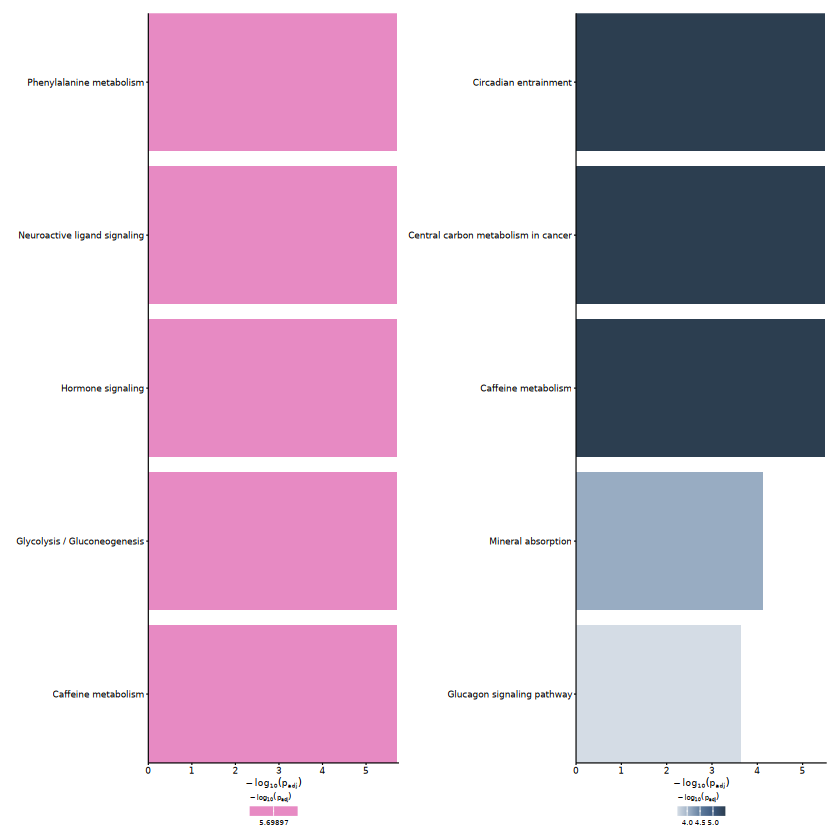

In [6]:
output_dir <- "/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment"
n_show <- 5
fig_width_mm <- 88
base_pt <- 5
# Gradients for -log10(p): light -> dark
gradient_pink <- c("#FDE0E6", "#F4A6B8", "#E78AC3", "#D64D7A", "#B71C5C")
gradient_blue <- c("#D4DCE5", "#9BAEC4", "#5C7A9B", "#3D5A80", "#2C3E50")

# Read both result tables
tab_pos <- read.csv(file.path(result_dir, "FELLA_pathway_enrichment_estimate_positive.csv"))
tab_neg <- read.csv(file.path(result_dir, "FELLA_pathway_enrichment_estimate_negative.csv"))

# One barplot: top N pathways, fill = neglog10padj, given gradient colors
make_barplot <- function(tab, fill_gradient) {
  pathway_only <- tab[tab$Entry.type == "pathway", ]
  if (nrow(pathway_only) == 0) return(ggplot() + theme_void())
  pathway_only$padj <- p.adjust(pathway_only$p.score, method = "BH")
  pathway_only$neglog10padj <- -log10(pathway_only$padj)
  pathway_only <- pathway_only[order(pathway_only$p.score), ][1:min(n_show, nrow(pathway_only)), ]
  # pathway_only <- pathway_only[order(pathway_only$padj), ]
  pathway_only$KEGG.name_short <- gsub(" \\- Homo.*$", "", pathway_only$KEGG.name)
  pathway_only$KEGG.name_short <- trimws(pathway_only$KEGG.name_short)
  pathway_only$KEGG.name_short <- substr(pathway_only$KEGG.name_short, 1, 55)
  x_max <- max(pathway_only$neglog10padj) * 1.01

  ggplot(pathway_only, aes(x = reorder(KEGG.name_short, neglog10padj), y = neglog10padj, fill = neglog10padj)) +
    geom_col() +
    coord_flip() +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_continuous(limits = c(0, x_max), expand = c(0, 0)) +
    scale_fill_gradientn(colors = fill_gradient, name = expression(-log[10](p[adj]))) +
    guides(fill = guide_colorbar(barwidth = 2, barheight = 0.4, title.position = "top", direction = "horizontal")) +
    labs(x = "", y = expression(-log[10](p[adj]))) +
    theme_classic(base_size = base_pt, base_family = "sans") +
    theme(
      legend.position = "bottom",
      legend.title = element_text(size = base_pt - 1),
      legend.text = element_text(size = base_pt - 1),
      axis.text = element_text(size = base_pt, colour = "black"),
      axis.title = element_text(size = base_pt, colour = "black"),
      axis.line = element_line(colour = "black", linewidth = 0.25),
      axis.ticks = element_line(colour = "black", linewidth = 0.25),
      panel.grid = element_blank(),
      plot.title = element_blank(),
      legend.margin = margin(0, 0, 0, 0),
      legend.box.spacing = unit(1, "pt")
    )
}

p_pos <- make_barplot(tab_pos, gradient_pink)
p_neg <- make_barplot(tab_neg, gradient_blue)

# Two panels side by side; each keeps its own legend (different color scale)
p_combined <- p_pos + p_neg + plot_layout(ncol = 2, widths = c(1, 1))

n_rows_max <- max(
   min(n_show, sum(tab_pos$Entry.type == "pathway")),
   min(n_show, sum(tab_neg$Entry.type == "pathway")),
  # sum(tab_pos$Entry.type == "pathway"),
  # sum(tab_neg$Entry.type == "pathway"),
  1
)
fig_height_mm <- max(50, n_rows_max * 10)

ggsave(
  file.path(output_dir, "FELLA_pathway_barplot_positive_negative_gender.pdf"),
  p_combined,
  width = fig_width_mm / 25.4,
  height = fig_height_mm / 25.4,
  units = "in",
  useDingbats = FALSE
)
message("Saved: ", file.path(output_dir, "FELLA_pathway_barplot_positive_negative_gender.pdf"))

print(p_combined)

In [7]:
save.image("/vol/projects/yzhang/500FG_aging/output/19_pathway_enrichment/metabolite_FELLA_pathway_positive_negative_gender.Rdata")